# 🧪 Notebook 05: Differential Expression Analysis (DEA) using Python

## 🎯 Introduction
Now that we have generated our raw counts matrix (`raw_counts.txt`), we will perform Differential Expression Analysis (DEA) to identify which genes are significantly up-regulated or down-regulated in response to the drug treatment.

### Objectives for this Notebook:
1. Load and clean the `raw_counts.txt` matrix using `pandas`.
2. Define the Experimental Design (Metadata/Design Matrix).
3. Perform Exploratory Data Analysis (EDA) using PCA (Principal Component Analysis) to check sample clustering.
4. Run Differential Expression Analysis (using PyDESeq2 or statistical libraries).
5. Visualize the results using a **Volcano Plot** and a **Heatmap**.

In [5]:
import pandas as pd
import numpy as np

# 1. Load the raw counts matrix (skip the first metadata line from featureCounts)
df = pd.read_csv('results/count_matrix/raw_counts.txt', sep='\t', skiprows=1)

# 2. Clean column names to keep only the Sample ID (SRRXXXXXXXX)
clean_columns = {}
for col in df.columns:
    if 'SRR' in col:
        sample_id = col.split('/')[-1].split('_')[0]
        clean_columns[col] = sample_id

df.rename(columns=clean_columns, inplace=True)

# 3. Separate Gene info and Transpose the matrix for PyDESeq2 (Samples must be rows)
df.set_index('Geneid', inplace=True)
sample_cols = ['SRR32812560', 'SRR32812561', 'SRR32812562', 'SRR32812566', 'SRR32812567', 'SRR32812572']
count_matrix = df[sample_cols].T  

# 4. Create the Metadata DataFrame mapping samples to conditions
metadata = pd.DataFrame({
    'Condition': ['Treated', 'Treated', 'Treated', 'Untreated', 'Untreated', 'Untreated']
}, index=sample_cols)

# Verify the alignment
print("🔍 --- METADATA MATRIX ---")
print(metadata)
print("\n📊 --- COUNT MATRIX PREVIEW (First 5 genes) ---")
print(count_matrix.iloc[:, :5])

🔍 --- METADATA MATRIX ---
             Condition
SRR32812560    Treated
SRR32812561    Treated
SRR32812562    Treated
SRR32812566  Untreated
SRR32812567  Untreated
SRR32812572  Untreated

📊 --- COUNT MATRIX PREVIEW (First 5 genes) ---
Geneid       Rv0001  Rv0002  Rv0003  Rv0004  Rv0005
SRR32812560    7532    1451    1369    1170   41122
SRR32812561    8810    1406    1441    1033   42873
SRR32812562    6224    1110    1182     830   29911
SRR32812566    6876    1374    1281    1068   34445
SRR32812567    5257     980     920     778   27490
SRR32812572    9864    1928    2190    1628   53080


## 📊 Step 2: Pre-filtering & Exploratory Data Analysis (PCA)

Before running the full differential expression model, we need to:
1. **Filter out low-count genes:** Genes with very low reads across all samples add noise and slow down calculations.
2. **Normalize the data:** Adjust for differences in sequencing depth using PyDESeq2's Size Factors.
3. **Perform PCA (Principal Component Analysis):** Visualize sample clustering to ensure biological replicates group together and conditions clearly separate.

✂️ Original genes: 3978
🧬 Remaining genes after filtering: 3964
Using None as control genes, passed at DeseqDataSet initialization


/tmp/ipykernel_1395/4053325546.py:13: DeprecationWarning: design_factors is deprecated and will soon be removed.Please consider providing a formulaic formula using the design argumentinstead.
  dds = DeseqDataSet(
Fitting size factors...
... done in 0.00 seconds.

/home/azureuser/miniconda3/envs/transcriptomics_env/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129516 (\N{DNA DOUBLE HELIX}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


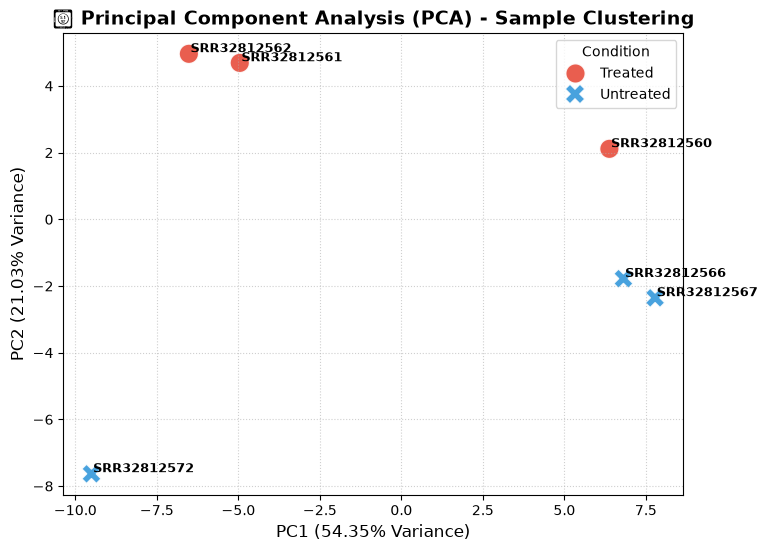

In [7]:
from pydeseq2.dds import DeseqDataSet
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Pre-filtering: Keep genes with a total sum of 10 or more reads across all 6 samples
genes_to_keep = count_matrix.columns[count_matrix.sum(axis=0) >= 10]
filtered_counts = count_matrix[genes_to_keep]
print(f"✂️ Original genes: {count_matrix.shape[1]}")
print(f"🧬 Remaining genes after filtering: {filtered_counts.shape[1]}")

# 2. Initialize DeseqDataSet to estimate Size Factors for normalization
dds = DeseqDataSet(
    counts=filtered_counts,
    metadata=metadata,
    design_factors="Condition"
)
dds.fit_size_factors()

normalized_counts = filtered_counts.div(dds.obs['size_factors'], axis=0)
log_counts = np.log2(normalized_counts + 1)

# 3. Compute PCA (reducing dimensions to PC1 and PC2)
pca = PCA(n_components=2)
pca_results = pca.fit_transform(log_counts)
var_exp = pca.explained_variance_ratio_ * 100  # Percentage of variance explained

# Create a clean DataFrame for plotting
pca_df = pd.DataFrame(pca_results, columns=['PC1', 'PC2'], index=count_matrix.index)
pca_df['Condition'] = metadata['Condition']

# 4. Plot the PCA
plt.figure(figsize=(8, 6))
colors = {'Treated': '#e74c3c', 'Untreated': '#3498db'} # Red for Treated, Blue for Untreated

sns.scatterplot(
    data=pca_df, x='PC1', y='PC2', hue='Condition', style='Condition',
    s=200, palette=colors, alpha=0.9
)

# Label each point with its Sample ID (SRR...)
for sample in pca_df.index:
    plt.text(pca_df.loc[sample, 'PC1'] + 0.05, pca_df.loc[sample, 'PC2'] + 0.05, sample, fontsize=9, weight='bold')

plt.title('🧬 Principal Component Analysis (PCA) - Sample Clustering', fontsize=14, weight='bold')
plt.xlabel(f'PC1 ({var_exp[0]:.2f}% Variance)', fontsize=12)
plt.ylabel(f'PC2 ({var_exp[1]:.2f}% Variance)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()